<div style="background: #1f2933; padding: 30px; border-radius: 14px; text-align: center; color: #f9fafb; box-shadow: 0px 4px 12px rgba(0,0,0,0.15); border-left: 5px solid #23a821ff;">

<h1 style="margin-bottom: 10px;">
📊 Exercise project 2 – Logistic regression (classification)</h1>

<h3 style="margin-top: 0; font-weight: 400; color: #fde68a;">
ML Model: Airline Passenger Satisfaction
</h3>

</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset name:</b>
</h4>

<a href="https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction/" 
   target="_blank"
   style="font-size:16px; color:#fde68a; text-decoration:none;">
Airline Passenger Satisfaction</a>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Dataset format:</b>
</h4>

<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Single CSV
</p>

</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

  <h4 style="margin:0; color:#f9fafb;">
    <b>Data description</b>
  </h4>

  <p style="margin:10px 0 6px 0; font-size:16px; color:#fde68a;">
    This dataset contains airline passenger satisfaction survey data. 
    Each row represents one passenger and includes demographic details, flight information, service ratings, and delay data. 
    The goal is to analyze factors influencing customer satisfaction and build a classification model to predict whether a passenger is satisfied or not.
  </p>

  <ul style="margin:6px 0 0 18px; padding:0; font-size:16px; color:#fde68a;">
    <li><b>Passenger Details</b> – Gender, Age, Customer Type</li>
    <li><b>Travel Information</b> – Class, Type of Travel, Flight Distance</li>
    <li><b>Service Ratings</b> – WiFi, Seat Comfort, Food, Boarding, Cleanliness, etc.</li>
    <li><b>Delay Information</b> – Departure and Arrival Delays</li>
    <li><b>Satisfaction</b> – Target variable (Satisfied / Neutral / Dissatisfied)</li>
  </ul>

  <p style="margin:12px 0 0 0; font-size:16px; color:#fde68a;">
    It is suitable for classification modeling, feature importance analysis, and customer experience analytics.
  </p>

</div>

<div style="background-color: #1f2933; border: 2px solid #22c55e; padding: 15px; border-radius: 8px; margin: 20px 0;">
    <h3 style="color: #f9fafb; margin-top: 0;">⚠️ Before You Start</h3>
    <p style="color: #fde68a; margin-bottom: 0;">
        <strong>Remember:</strong> Run each cell in order by clicking inside it and pressing <kbd>Shift</kbd> + <kbd>Enter</kbd>. Do not skip steps.
    </p>
</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #23a821ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 1 - Loading the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
    Code: Importing modules, custom functions and loading the data
</p>
</div>


In [99]:
# Usual imports in a classic ML pipeline for Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [100]:
# usual imports in a classic ML pipeline for Classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics, svm

# additional metrics ONLY for classification
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# let's add some helpful features like the pipelines
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.calibration import CalibratedClassifierCV

In [101]:
# usual imports in a classic ML pipeline for Regression
# pip install numpy
# pip install pandas
# pip install seaborn
# pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# some additional imports needed
from sklearn.model_selection import train_test_split
from sklearn import metrics, svm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import TransformedTargetRegressor

In [102]:
# loading the data
df = pd.read_csv("Airline_Passenger_Satisfaction.csv")
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> 🔬 STEP 2 - Exploring  the dataset</b>
</h3>
<p style="font-size:16px; color:#fde68a; text-decoration:none;">
   Code: Basic data checks, duplicates or missing values (NaN)?
</div>

In [103]:
# let's quickly see the first 5 rows of data
df.head(5)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied


In [104]:
# printing total no.s of rows and columns of whole dataset
df.shape

(25976, 25)

In [105]:
# checking column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25976 non-null  int64  
 1   id                                 25976 non-null  int64  
 2   Gender                             25976 non-null  object 
 3   Customer Type                      25976 non-null  object 
 4   Age                                25976 non-null  int64  
 5   Type of Travel                     25976 non-null  object 
 6   Class                              25976 non-null  object 
 7   Flight Distance                    25976 non-null  int64  
 8   Inflight wifi service              25976 non-null  int64  
 9   Departure/Arrival time convenient  25976 non-null  int64  
 10  Ease of Online booking             25976 non-null  int64  
 11  Gate location                      25976 non-null  int

In [106]:
# getting statistical summary of the dataframe
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.000000,25976.00000,25893.000000
mean,12987.500000,65005.657992,39.620958,1193.788459,2.724746,3.046812,2.756775,2.977094,3.215353,3.261665,3.449222,3.357753,3.385664,3.350169,3.633238,3.314175,3.649253,3.286226,14.30609,14.740857
std,7498.769632,37611.526647,15.135685,998.683999,1.335384,1.533371,1.412951,1.282133,1.331506,1.355536,1.320090,1.338299,1.282088,1.318862,1.176525,1.269332,1.180681,1.319330,37.42316,37.517539
min,0.000000,17.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,6493.750000,32170.500000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.00000,0.000000
50%,12987.500000,65319.500000,40.000000,849.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,19481.250000,97584.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.00000,13.000000
max,25975.000000,129877.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1128.00000,1115.000000


---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Cleaning</b>
</h2>
</div>


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

<h4 style="margin:0; color:#f9fafb;">
<b>Handling missing/duplicate values and 
HANDLE ALL CATEGORICAL VARIABLES CORRECTLY</b>
</h4>
</div>


<h3>
<strong style='color:orange ;'>Data cleanup procedure and getting the ready data for training the Ml model
 </strong>
</h3>




In [107]:
# checking the nan values in the dataset
df.isna().sum() 

Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0


In [108]:
# dropping nan values from the dataset
df = df.dropna()

In [109]:
# checking duplicates 

duplicates = df.duplicated().sum()
print(duplicates)

0


In [110]:
# dropping these columns as it is not useful for our analysis and prediction

df = df.drop(columns=['id'], axis=1)
df = df.drop(columns=['Unnamed: 0'], axis=1)

In [111]:
# printing total no.s of rows and columns of whole dataset after dropping the some columns
df.shape

(25893, 23)

In [112]:
# printing columns names of the dataset

column = df.columns
print(column)

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


In [113]:
# creating a summary dataframe to get the unique values and missing values in each column of the dataset
# after dropping the nan values, there should not be any missing values in the dataset 
# but we are creating this summary dataframe to get the unique values in each column of the dataset, 
# so that if we had missed some insights about the dataset, then we can get it from this summary dataframe

summary = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Missing Values": [df[col].isnull().sum() for col in df.columns]
})
print(summary)

                               Column  Unique Values  Missing Values
0                              Gender              2               0
1                       Customer Type              2               0
2                                 Age             75               0
3                      Type of Travel              2               0
4                               Class              3               0
5                     Flight Distance           3279               0
6               Inflight wifi service              6               0
7   Departure/Arrival time convenient              6               0
8              Ease of Online booking              6               0
9                       Gate location              5               0
10                     Food and drink              6               0
11                    Online boarding              6               0
12                       Seat comfort              5               0
13             Inflight entertainm

<div style="border: 4px solid #23a821ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>The dataset has <b>25,976 rows</b> and <b>23 columns after filtering.</b></li>
    <li>Most columns are numeric.</li>
    <li>I dropped ID column and Unnamed: 0 because it would not help with analysis or prediction but can make problem while training the ml model.</li>
    <li>There were null values in the dataset so I dropped those.</li>
    <li>In the summary which I have created we can see that there is one specific column named "flight distance" that as highest unique values among other columns, so no need to convert or transform this columns any more as it distance and already in numeric. And also no need to transform "Departure Delay in Minutes" and "Arrival Delay in Minutes" and there might some more columns that we might not need to transform.  </li>

 
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

<h2 style="margin:0; color:#f9fafb;">
<b>Data Preparation</b>
</h2>
</div>


<h3>
<strong style='color:orange ;'>Case 1: Binary variables (only two options)
 </strong>
</h3>




In [114]:
# checking the binary columns in the dataset

binary_cols  = [c for c in df.columns if df[c].nunique(dropna=True) == 2]
binary_cols

['Gender', 'Customer Type', 'Type of Travel', 'satisfaction']

In [115]:
# mapping the target variable into binary format (0 and 1)
# Satisfaction 

target_mapping = {
    "satisfied": 1, 
    "neutral or dissatisfied": 0
}

df["satisfaction"] = df["satisfaction"].map(target_mapping)

In [116]:
# mapping the target variable into binary format (0 and 1)
# Gender 

target_mapping = {
    "Male": 1, 
    "Female": 0
}

df["Gender"] = df["Gender"].map(target_mapping)

In [117]:
# mapping the target variable into binary format (0 and 1)
# Customer Type 

target_mapping = {
    "Loyal Customer": 1, 
    "disloyal Customer": 0
}

df["Customer Type"] = df["Customer Type"].map(target_mapping)

In [118]:
# mapping the target variable into binary format (0 and 1)
# Type of Travel

target_mapping = {
    "Business travel": 1, 
    "Personal Travel": 0
}

df["Type of Travel"] = df["Type of Travel"].map(target_mapping)

<h3>
<strong style='color:orange ;'>Case 2: Ordinal variables (categories that have an order/rank -> can be compared)
</strong>
</h3>




In [119]:
# ordinal encoding for the "Class" column

cut_mapping = {
    "Business": 1,
    "Eco Plus": 2,
    "Eco": 3
}

df["Class"] = df["Class"].map(cut_mapping)  

In [120]:
df.head(5)

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,1,52,1,3,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,1
1,0,1,36,1,1,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,1
2,1,0,20,1,3,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,0
3,1,1,44,1,1,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,1
4,0,1,49,1,3,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,1


<div style="border: 4px solid #23a821ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>There are 25 columns in the dataset after dropping 2 columns, we are left with 23 columns among which there are 4 columns that I treated as binary, 1 column (Class) as ordinal and rest of them as nominal  </li>
 
  </ul>
</div>

---

<Axes: xlabel='satisfaction', ylabel='Count'>

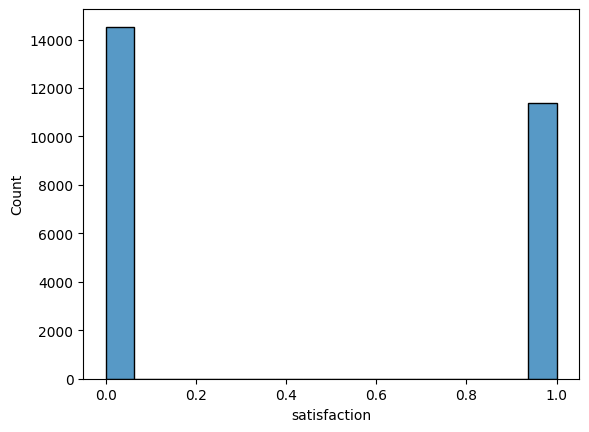

In [121]:
# creating a histplot to see the distribution of the target variable "satisfaction" 
sns.histplot(data=df, x="satisfaction")

In [122]:
# checking the value counts of the target variable "satisfaction" 
df["satisfaction"].value_counts()

satisfaction
0    14528
1    11365
Name: count, dtype: int64

<div style="border: 4px solid #23a821ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: DISTRIBUTION
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <b>By looking at the histplot and the value counts, it clearly shows that the distribution is healthy</b>. 
    
  </p>

</div>

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 3: X/y and train/test -split</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Data preparation as X and Y</b>
</h3>


In [123]:
# first step, we split our data into SUPPORT variables and the TARGET variable
# X => support variables, y => target variable

# X => list of support variables the model uses 
# while predicting the target variable with the model
X = df.drop("satisfaction", axis=1)

# our target variable is y
y = df["satisfaction"]

<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>


In [124]:
# secondly, train/test -split with scikit-learn's helper function
# 0.3 for testing => 30% of data is reserved for testing purposes
# and based on that => it's deduced that 70% will be in the training data

# you can also define the random state, which is sometimes useful
# if you want to "lock down" all the randomness in order to get same results every time
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

<div style="border: 4px solid #23a821ff; padding:14px 18px; background:#1f2933; margin:10px 0; border-radius:10px; width: fit-content;">

  <h2 style="color:#f9fafb; margin:0 0 8px 0; font-size:2em; letter-spacing:3px;">
     🔑 KEY INSIGHT: Training the X and the y split
  </h2>

  <p style="margin:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    I have used the 30 70 split for this model

  </p>

</div>

### We can automatically search for optimal hyperparameters in our algorithms

**We'll use GridSearchCV in this example (automatically try all given combinations of parameters)**

In [ ]:
from sklearn.model_selection import GridSearchCV

# initialize testable parameters
# NOTE! all algorithms do not support all parameters
# see notes in Moodle which algorithms support which parameters
param_grid = {
    'C': [0.1, 0.5, 1, 1.25, 1.5, 2.0],
    'gamma': [1, 0.25, 0.1, 0.05, 0.01], 
}

# start finding the optimal parameters with GridSearchCV!
test_model = GridSearchCV(svm.SVR(kernel="rbf"), param_grid, refit=True, verbose=3)
test_model.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ...................C=0.1, gamma=1;, score=-0.300 total time=  12.6s
[CV 2/5] END ...................C=0.1, gamma=1;, score=-0.276 total time=  10.7s
[CV 3/5] END ...................C=0.1, gamma=1;, score=-0.300 total time=  12.1s
[CV 4/5] END ...................C=0.1, gamma=1;, score=-0.258 total time=  12.3s
[CV 5/5] END ...................C=0.1, gamma=1;, score=-0.248 total time=  11.6s
[CV 1/5] END ................C=0.1, gamma=0.25;, score=-0.299 total time=  12.1s
[CV 2/5] END ................C=0.1, gamma=0.25;, score=-0.275 total time=  11.2s
[CV 3/5] END ................C=0.1, gamma=0.25;, score=-0.299 total time=  12.3s
[CV 4/5] END ................C=0.1, gamma=0.25;, score=-0.257 total time=  12.4s
[CV 5/5] END ................C=0.1, gamma=0.25;, score=-0.247 total time=  12.2s
[CV 1/5] END .................C=0.1, gamma=0.1;, score=-0.289 total time=  11.1s
[CV 2/5] END .................C=0.1, gamma=0.1;

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.5, ...], 'gamma': [1, 0.25, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate paramet

In [ ]:
# print the best combination of the parameters
test_model.best_params_

{'C': 1, 'gamma': 0.01}

In [ ]:
# based on search, these are our optimal parameters in the given ranges
# {'C': 1, 'gamma': 0.01}

<h3 style='color:orange'>
  <b>Data is good to go (all numbers) => train model etc.
</b>
</h3>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>STEP 4: Create and train the ML model</b>
</h3>
</div>


<h3 style='color:orange'>
  <b>Train the logistic regression model
</b>
</h3>

In [ ]:
# create the model and train it with the data
# use pipeline to scale the X-values automatically with StandardScaler!!
pipeline = make_pipeline(
    StandardScaler(), 
    svm.SVR(C=2, gamma=0.1, kernel='rbf')
)

# thanks to TransformedTargetRegressor, we can also automate
# the y-scaling!!!
model = TransformedTargetRegressor(
    regressor=pipeline,
    transformer=MinMaxScaler()
)

# train model normally
model.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step... gamma=0.1))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",MinMaxScaler()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1


<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid #23a821ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> STEP 5: Classification error metrics</b>
</h3>
</div>


In [ ]:
# we need to create test predictions based on our earlier reserved test dataset
# this data has never been seen by the model by now

# THESE PREDICTIONS ARE IN SCALED FORMAT
predictions = model.predict(X_test)

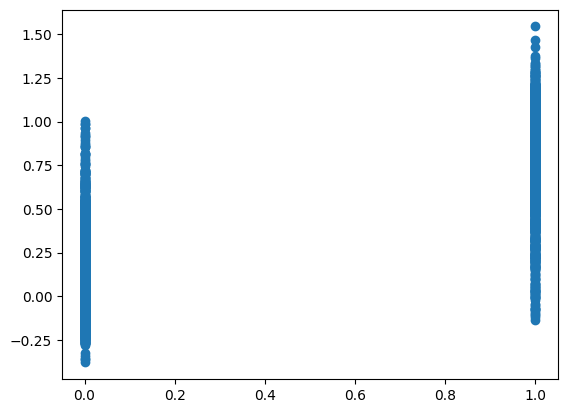

In [ ]:
# let's plot how far the predictions are from the real target values (y)
# in the test dataset

# if the values follow a diagonal line (from bottom left to top right)
# => we have good predictions with the model
# we basically compare the predicted values to the actual true values 
# and compare the differences
plt.scatter(y_test, predictions)
plt.show()

In [ ]:
# MAE = Mean average error
mae = metrics.mean_absolute_error(y_test, predictions)
print("MAE:")
print(f"{round(mae, 2)} $")

# MSE = Mean squared error
mse = metrics.mean_squared_error(y_test, predictions)
print("\nMSE:")
print(f"{round(mse, 2)} $^2")

# RMSE = Root Mean Squared Error
rmse = np.sqrt(mse)
print("\nRMSE:")
print(f"{round(rmse, 2)} $")

# R-square (or R2) - how well the model describes the original dataset
# 1 => model describes the data perfectly
# 0 => model doesn't describe the data at all
r2 = metrics.r2_score(y_test, predictions)
print("\nR-squared:")
print(f"{round(r2, 2)}")

# SCALED VERSIONS OF THE METRICS, only use MAE and RMSE
y_test_scaled = model.transformer_.transform(y_test.values.reshape(-1, 1)).ravel()
predictions_scaled = model.transformer_.transform(predictions.reshape(-1, 1)).ravel()

# calculate the scaled MAE/RMSE
mae_scaled = metrics.mean_absolute_error(y_test_scaled, predictions_scaled)
rmse_scaled = np.sqrt(metrics.mean_squared_error(y_test_scaled, predictions_scaled))

print(f"\nMAE scaled: {round(mae_scaled, 2)}")
print(f"\nRMSE scaled: {round(rmse_scaled, 2)}")

MAE:
0.14 $

MSE:
0.05 $^2

RMSE:
0.22 $

R-squared:
0.8

MAE scaled: 0.14

RMSE scaled: 0.22


/var/folders/yy/4vrmj46n0_53mpnmp8clw2fh0000gn/T/ipykernel_30860/2920752686.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test - predictions))


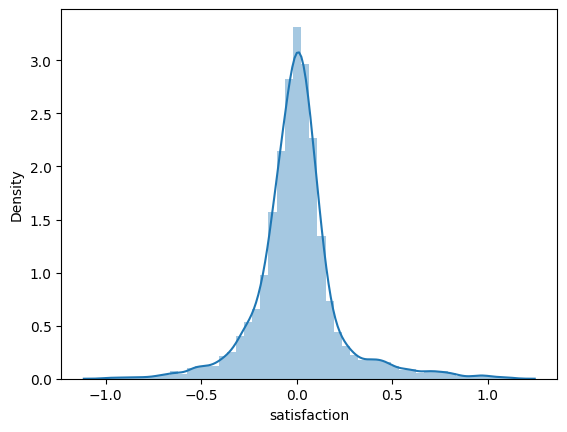

In [ ]:
# if the prediction distribution is far from standard normal distritbuion
# then the model is not probably good enough
# distplot is deprecated and will be removed in future seaborn versions
# but not direct replacement has been created so far
sns.distplot((y_test - predictions))
plt.show()
plt.close()

<div style="border: 4px solid #23a821ff; padding: 10px 12px; background: #1f2933; margin: 10px 0; text-align: left; border-radius: 10px;">
  <h2 style="color: #f9fafb; margin: 0 0 8px 0; font-size: 2em; letter-spacing: 3px;">
    OBSERVATIONS:
  </h2>

  <ul style="margin: 0 0 12px 18px; padding:0; color:#e5e7eb; font-size:16px; line-height:1.6;">
    <li>Model trains without crashing so that's a nice and it means the column are converted properly </li>
 
  </ul>
</div>

---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #23a821ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b> AI Usage</b>
</h3>
</div>


<h3>
<strong style='color:orange ;'>Yes (for html and style)
 </strong>
</h3>




---

<div style="background-color:#1f2933; padding:14px 18px; border-radius:10px; border-left:5px solid  #23a821ff; width: fit-content;">

<h3 style="margin:0; color:#f9fafb;">
<b>Teachers feedback:</b>
</h3>
</div>


<h3>
<strong style='color:orange ;'>Question: Opettaja how compare this with SVC and LR models? 
 </strong>
</h3>


